# PINN Heston 3D

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    torch.set_float32_matmul_precision('high')

Using device: cpu


/Users/romainchevrot/.Python_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Fast Heston Pricer

In [2]:
class HestonPricer:
    """
    Vectorised Heston call pricer via Gil-Pelaez Fourier inversion.
    Uses pre-computed Gauss-Legendre nodes on [0, U].

    C(S, K, tau) = S * P1  -  K * exp(-r*tau) * P2
    """

    def __init__(self, r, kappa, theta, sigma, rho, U=120.0, n_pts=64):
        self.r, self.kappa, self.theta = r, kappa, theta
        self.sigma, self.rho           = sigma, rho
        # Gauss-Legendre nodes mapped to [0, U]
        x, w       = np.polynomial.legendre.leggauss(n_pts)
        self.u     = 0.5 * U * (x + 1.0)         # shape (n_pts,)
        self.w     = 0.5 * U * w                  # shape (n_pts,)

    # ------------------------------------------------------------------
    def _cf(self, u, v, tau, j):
        """Heston characteristic function for P_j, fully vectorised."""
        kappa, theta = self.kappa, self.theta
        sigma, rho, r = self.sigma, self.rho, self.r
        # u: (...) float array,  v/tau: scalars
        if j == 1:
            u_j, b_j = 0.5, kappa - rho * sigma
        else:
            u_j, b_j = -0.5, kappa

        a  = kappa * theta
        iu = 1j * u
        d  = np.sqrt((rho * sigma * iu - b_j)**2
                     - sigma**2 * (2 * u_j * iu - u**2))
        bp = b_j - rho * sigma * iu
        g  = (bp + d) / (bp - d)

        C  = (r * iu * tau
              + (a / sigma**2) * (
                    (bp + d) * tau
                    - 2.0 * np.log((1.0 - g * np.exp(d * tau)) / (1.0 - g))
              ))
        D  = ((bp + d) / sigma**2
              * (1.0 - np.exp(d * tau)) / (1.0 - g * np.exp(d * tau)))

        # C, D: (n_pts,)   v, tau: scalar -> broadcast OK
        return np.exp(C + D * v)          # (n_pts,)  [log(S) factor added below]

    def _P_j(self, j, S_arr, K_arr, v, tau):
        """
        P_j for arrays of S and K (same length).
        Returns array of shape (N,).
        """
        u       = self.u                          # (n_pts,)
        cf_vals = self._cf(u, v, tau, j)          # (n_pts,)
        logS    = np.log(np.maximum(S_arr, 1e-12))  # (N,)
        logK    = np.log(np.maximum(K_arr, 1e-12))  # (N,)

        # outer product: exp(i*u*(logS - logK))  ->  (N, n_pts)
        phase = np.exp(1j * np.outer(logS - logK, u))  # (N, n_pts)
        integrand = (phase * cf_vals[np.newaxis, :] / (1j * u[np.newaxis, :])).real
        return 0.5 + (integrand @ self.w) / np.pi    # (N,)

    def price(self, S, K, v, tau, option_type="call"):
        S   = max(float(S), 1e-12)
        v   = max(float(v), 1e-12)
        tau = max(float(tau), 0.0)
        K   = float(K)

        if tau < 1e-8:
            c = max(S - K, 0.0)
            return c if option_type == "call" else max(c - S + K * math.exp(-self.r * tau), 0.0)

        # ── NEW: deep-OTM early exit ──────────────────────────────────────────
        if math.log(S / K) < -2.0:
            return 0.0 if option_type == "call" else max(K * math.exp(-self.r * tau) - S, 0.0)

        S_a = np.array([S]); K_a = np.array([K])
        P1  = self._P_j(1, S_a, K_a, v, tau)[0]
        P2  = self._P_j(2, S_a, K_a, v, tau)[0]
        c   = S * P1 - K * math.exp(-self.r * tau) * P2
        c   = max(c, 0.0)
        return c if option_type == "call" else max(c - S + K * math.exp(-self.r * tau), 0.0)
    
    def price_grid(self, S_arr, K, v, tau):
        """
        Vectorised: price len(S_arr) calls at once.  K is scalar.
        Returns numpy array of call prices.
        """
        S_arr = np.maximum(np.asarray(S_arr, dtype=float), 1e-12)
        K_f   = float(K)

        # ── Guard 1: near-expiry (mirrors the check in price()) ──────────────
        if tau < 1e-8:
            return np.maximum(S_arr - K_f, 0.0)

        # ── Guard 2: deep-OTM mask ────────────────────────────────────────────
        # When log(S/K) << 0 the integrand in _P_j oscillates at frequency
        # |log(S/K)| / (2π).  With U=120, n_pts=64 the average node spacing
        # is ~1.875; below log(S/K) ≈ -3 the oscillation period falls below
        # ~2 node spacings and the GL quadrature aliases → spurious spike.
        # At log(S/K) < -3 the true call price is < 1e-10 for any
        # reasonable parameter set, so returning 0 is exact to all purposes.
        log_m   = np.log(S_arr / K_f)          # negative for OTM
        otm     = log_m < -2.0                 # True where quadrature fails

        prices  = np.zeros_like(S_arr)
        valid   = ~otm

        if valid.any():
            S_v = S_arr[valid]
            K_a = np.full_like(S_v, K_f)
            P1  = self._P_j(1, S_v, K_a, v, tau)
            P2  = self._P_j(2, S_v, K_a, v, tau)
            prices[valid] = np.maximum(S_v * P1 - K_f * math.exp(-self.r * tau) * P2, 0.0)

        return prices


## PINN Class 

In [3]:
class PINN_Heston_Continuous(nn.Module):
    def __init__(
        self,
        K, r, kappa, theta, sigma, rho, T,
        S_min, S_max, v_min, v_max, t_min, t_max,
        hidden_layers,
        activation_fun=nn.Tanh,
        loss_weights=None,
        atm_fraction=0.4,
        atm_bandwidth=0.25,
    ):
        super().__init__()

        # PDE parameters
        self.K, self.r         = K, r
        self.kappa, self.theta = kappa, theta
        self.sigma, self.rho   = sigma, rho
        self.T                 = T

        # Domain
        self.S_min, self.S_max = S_min, S_max
        self.v_min, self.v_max = v_min, v_max
        self.t_min, self.t_max = t_min, t_max

        # ATM band
        self.atm_fraction  = atm_fraction
        self.atm_bandwidth = atm_bandwidth
        self.S_atm_lo      = K * (1.0 - atm_bandwidth)
        self.S_atm_hi      = K * (1.0 + atm_bandwidth)

        self.mse = nn.MSELoss()

        if loss_weights is None:
            loss_weights = {
                "pde": 1.0, "terminal": 10.0,
                "boundary_S0": 1.0, "boundary_Smax": 5.0,
                "boundary_v0": 5.0, "boundary_vmax": 1.0,
            }
        self.loss_weights = loss_weights

        # Network  (3 → hidden → 1)
        layers = [nn.Linear(3, hidden_layers[0]), activation_fun()]
        for i in range(len(hidden_layers) - 1):
            layers += [nn.Linear(hidden_layers[i], hidden_layers[i+1]), activation_fun()]
        layers.append(nn.Linear(hidden_layers[-1], 1))
        self.net = nn.Sequential(*layers)

        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight, gain=nn.init.calculate_gain("tanh"))
                nn.init.zeros_(m.bias)

    # ── forward ──────────────────────────────────────────────────────────────
    def forward(self, S, v, t):
        x = torch.cat([S, v, t], dim=1)
        # [-1, 1] scaling
        x_s = torch.stack([
            2.0 * (x[:, 0] - self.S_min) / (self.S_max - self.S_min) - 1.0,
            2.0 * (x[:, 1] - self.v_min) / (self.v_max - self.v_min) - 1.0,
            2.0 * (x[:, 2] - self.t_min) / (self.t_max - self.t_min) - 1.0,
        ], dim=1)
        return F.softplus(self.net(x_s))

    def _grad(self, y, x):
        return torch.autograd.grad(
            y, x, grad_outputs=torch.ones_like(y),
            create_graph=True, retain_graph=True
        )[0]

    # ── PDE residual (with optional gradient checkpointing) ──────────────────
    def _residual_core(self, S, v, t):
        V = self.forward(S, v, t)

        # ── first order: one graph traversal instead of three ──
        V_t, V_S, V_v = torch.autograd.grad(V, [t, S, v],grad_outputs=torch.ones_like(V),
                                            create_graph=True, retain_graph=True)

        # ── second order: one traversal for V_SS and V_Sv together ──
        V_SS, V_Sv = torch.autograd.grad(V_S, [S, v], grad_outputs=torch.ones_like(V_S),
                                         create_graph=True, retain_graph=True)

        # ── second order: V_vv separately (different source node) ──
        V_vv = torch.autograd.grad(V_v, v, grad_outputs=torch.ones_like(V_v), create_graph=True)[0]

        return (V_t
                + 0.5 * v * S**2 * V_SS
                + self.rho * self.sigma * v * S * V_Sv
                + 0.5 * self.sigma**2 * v * V_vv
                + self.r * S * V_S
                + self.kappa * (self.theta - v) * V_v
                - self.r * V)

    def heston_pde_residual(self, S, v, t):
        S = S.detach().requires_grad_(True)
        v = v.detach().requires_grad_(True)
        t = t.detach().requires_grad_(True)
        return self._residual_core(S, v, t)

    # ── ATM-focused S sampler ─────────────────────────────────────────────────
    def _sample_S_atm(self, N, dev):
        eps   = 1e-6
        N_atm = int(N * self.atm_fraction)
        N_gl  = N - N_atm
        S_atm = (torch.rand(N_atm, 1, device=dev)
                 * (self.S_atm_hi - self.S_atm_lo) + self.S_atm_lo)
        S_gl  = torch.rand(N_gl, 1, device=dev) * (self.S_max - eps) + eps
        return torch.cat([S_atm, S_gl], dim=0)

    def _sample_S_terminal(self, N, dev):
        N_kink = int(N * 0.70)
        N_rest = N - N_kink
        S_kink = torch.rand(N_kink, 1, device=dev) * 20.0 + (self.K - 10.0)  # [90, 110]
        S_rest = torch.rand(N_rest, 1, device=dev) * (self.S_max - 1e-6) + 1e-6
        return torch.cat([S_kink, S_rest], dim=0)

    # ── collocation sampler ───────────────────────────────────────────────────
    def sample_training_points(self, N_f, N_terminal, N_b):
        dev = next(self.parameters()).device
        eps = 1e-6

        S_f  = self._sample_S_atm(N_f, dev)
        v_f  = torch.rand(N_f,  1, device=dev) * (self.v_max - eps) + eps
        t_f  = torch.rand(N_f,  1, device=dev) * (self.t_max - self.t_min) + self.t_min

        S_T = self._sample_S_terminal(N_terminal, dev)
        v_T  = torch.rand(N_terminal, 1, device=dev) * (self.v_max - self.v_min) + self.v_min
        t_T  = torch.full((N_terminal, 1), self.T, device=dev)

        S_b0  = torch.zeros(N_b, 1, device=dev)
        v_b0  = torch.rand(N_b, 1, device=dev) * (self.v_max - self.v_min) + self.v_min
        t_b0  = torch.rand(N_b, 1, device=dev) * (self.t_max - self.t_min) + self.t_min

        S_b1  = torch.full((N_b, 1), self.S_max, device=dev)
        v_b1  = torch.rand(N_b, 1, device=dev) * (self.v_max - self.v_min) + self.v_min
        t_b1  = torch.rand(N_b, 1, device=dev) * (self.t_max - self.t_min) + self.t_min

        S_bv0 = self._sample_S_terminal(N_b, dev)
        v_bv0 = torch.zeros(N_b, 1, device=dev)
        t_bv0 = torch.rand(N_b, 1, device=dev) * (self.t_max - self.t_min) + self.t_min

        S_bv1 = torch.rand(N_b, 1, device=dev) * (self.S_max - self.S_min) + self.S_min
        v_bv1 = torch.full((N_b, 1), self.v_max, device=dev)
        t_bv1 = torch.rand(N_b, 1, device=dev) * (self.t_max - self.t_min) + self.t_min

        return (S_f,  v_f,  t_f,
                S_T,  v_T,  t_T,
                S_b0, v_b0, t_b0,
                S_b1, v_b1, t_b1,
                S_bv0,v_bv0,t_bv0,
                S_bv1,v_bv1,t_bv1)

    def compute_loss_from_data(self, data, pde_weight_override=None):
        (S_f, v_f, t_f,
        S_T, v_T, t_T,
        S_b0, v_b0, t_b0,
        S_b1, v_b1, t_b1,
        S_bv0,v_bv0,t_bv0,
        S_bv1,v_bv1,t_bv1) = data

        # PDE residual
        res      = self.heston_pde_residual(S_f, v_f, t_f)
        loss_pde = self.mse(res, torch.zeros_like(res))

        # Terminal condition: V(S, v, T) = max(S - K, 0)
        V_T      = self.forward(S_T, v_T, t_T)
        loss_ter = self.mse(V_T, torch.clamp(S_T - self.K, min=0.0))

        # S=0 boundary: V(0, v, t) = 0
        V_b0     = self.forward(S_b0, v_b0, t_b0)
        loss_b0  = self.mse(V_b0, torch.zeros_like(V_b0))

        # S=Smax boundary: V(Smax, v, t) = Smax - K*exp(-r*(T-t))
        V_b1     = self.forward(S_b1, v_b1, t_b1)
        tgt_b1   = S_b1 - self.K * torch.exp(-self.r * (self.T - t_b1))
        loss_b1  = self.mse(V_b1, tgt_b1)

        # v=0 boundary: V(S, 0, t) = max(S - K*exp(-r*(T-t)), 0)
        V_bv0    = self.forward(S_bv0, v_bv0, t_bv0)
        tgt_bv0  = torch.clamp(S_bv0 - self.K * torch.exp(-self.r * (self.T - t_bv0)), min=0.0)
        loss_bv0 = self.mse(V_bv0, tgt_bv0)

        # v=vmax boundary: Dirichlet V(S, v_max, t) = S
        # As v -> inf the call price -> S (option certain to expire ITM)
        V_bv1    = self.forward(S_bv1, v_bv1, t_bv1)
        loss_bv1 = self.mse(V_bv1, S_bv1)

        w_pde = pde_weight_override if pde_weight_override is not None else self.loss_weights["pde"]
        loss  = (w_pde                               * loss_pde
                + self.loss_weights["terminal"]      * loss_ter
                + self.loss_weights["boundary_S0"]   * loss_b0
                + self.loss_weights["boundary_Smax"] * loss_b1
                + self.loss_weights["boundary_v0"]   * loss_bv0
                + self.loss_weights["boundary_vmax"] * loss_bv1)

        return loss, {
            "loss_pde":      loss_pde.item(),
            "loss_terminal": loss_ter.item(),
            "loss_b0":       loss_b0.item(),
            "loss_b1":       loss_b1.item(),
            "loss_bv0":      loss_bv0.item(),
            "loss_bv1":      loss_bv1.item()}

    def compute_loss(self, N_f, N_terminal, N_b, pde_weight_override=None):
        data = self.sample_training_points(N_f, N_terminal, N_b)
        return self.compute_loss_from_data(data, pde_weight_override=pde_weight_override)


## Initialisation

In [4]:
torch.manual_seed(42)
np.random.seed(42)

# Heston parameters
K     = 100.0
r     = 0.05
kappa = 2.0
theta = 0.04
sigma = 0.30
rho   = -0.70
T     = 1.0
v0    = 0.04

# Domain
S_min, S_max = 0.0,  200.0
v_min, v_max = 0.0,  1.0
t_min, t_max = 0.0,  T

# Collocation sizes
N_f        = 20_000
N_terminal = 10_000
N_b        = 3_000

# Network
hidden_layers = [256, 256, 256, 256]
activation_fun = nn.SiLU

loss_weights = {
                "pde": 1.0,
                "terminal": 200.0,
                "boundary_S0": 1.0, 
                "boundary_Smax": 10.0,
                "boundary_v0": 10.0, 
                "boundary_vmax": 5.0
                }

lr     = 5e-4
epochs = 5_000
# Re-sample collocation points every N epochs (reduces CPU-GPU overhead)
resample_every = 75

heston = HestonPricer(r, kappa, theta, sigma, rho)

model = PINN_Heston_Continuous(K, r, kappa, theta, sigma, rho, T,
                               S_min, S_max, v_min, v_max, t_min, t_max,
                               hidden_layers, activation_fun, loss_weights,
                               atm_fraction=0.6, atm_bandwidth=0.2).to(device)
model_eval = model 

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"ATM band: [{K*(1-0.25):.0f}, {K*(1+0.25):.0f}]")
print(f"Resample collocation every {resample_every} epochs")


Parameters: 198,657
ATM band: [75, 125]
Resample collocation every 75 epochs


## Training

In [5]:
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

USE_AMP = False
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

data = model.sample_training_points(N_f, N_terminal, N_b)

adam_start_time = time.time()

history = {"epoch": [], "total_loss": [], "pde_loss": [], "terminal_loss": [],
           "S0_loss": [], "Smax_loss": [], "v0_loss": [], "vmax_loss": [], "pde_weight": []}

# Best checkpoint tracking
best_loss  = float('inf')
best_state = None

pbar = tqdm(range(1, epochs + 1), desc="Adam training", dynamic_ncols=True, disable=False)

for epoch in pbar:

    if epoch % resample_every == 1:
        data = model.sample_training_points(N_f, N_terminal, N_b)

    optimizer.zero_grad(set_to_none=True)

    pde_w = 1.0 + 9.0 * min(epoch / 2_000, 1.0)  # was 4_000

    with torch.autocast(device_type=device.type, enabled=USE_AMP):
        loss, parts = model.compute_loss_from_data(data, pde_weight_override=pde_w)

    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    scaler.step(optimizer)
    scaler.update()
    scheduler.step()

    # Save best checkpoint
    if loss.item() < best_loss:
        best_loss  = loss.item()
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    # Reduced logging frequency
    if epoch % 50 == 0 or epoch == 1:
        history["epoch"].append(epoch)
        history["total_loss"].append(loss.item())
        history["pde_loss"].append(parts["loss_pde"])
        history["terminal_loss"].append(parts["loss_terminal"])
        history["S0_loss"].append(parts["loss_b0"])
        history["Smax_loss"].append(parts["loss_b1"])
        history["v0_loss"].append(parts["loss_bv0"])
        history["vmax_loss"].append(parts["loss_bv1"])
        history["pde_weight"].append(pde_w)

    pbar.set_postfix(loss=f"{loss.item():.3e}", best=f"{best_loss:.3e}", pde_w=f"{pde_w:.1f}")

    if epoch % 1000 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:5d} | "
            f"Total: {loss.item():.4e} | "
            f"PDE(w={pde_w:.1f}): {parts['loss_pde']:.3e} | "
            f"Terminal: {parts['loss_terminal']:.3e} | "
            f"S=0: {parts['loss_b0']:.3e} | "
            f"S=max: {parts['loss_b1']:.3e} | "
            f"v=0: {parts['loss_bv0']:.3e} | "
            f"v=max: {parts['loss_bv1']:.3e}"
        )

adam_time = time.time() - adam_start_time

# Restore best weights before L-BFGS
print(f"\nAdam training complete in {adam_time:.2f} seconds.")
print(f"Restoring best checkpoint (loss={best_loss:.4e})...")
model.load_state_dict(best_state)

# L-BFGS fine-tuning
print("\nStarting L-BFGS fine-tuning...")
lbfgs_start_time = time.time()

fixed_data = model.sample_training_points(N_f, N_terminal, N_b)

opt_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    lr=1.0,
    max_iter=1_000,
    max_eval=2500,
    history_size=50,
    line_search_fn="strong_wolfe")

def closure():
    opt_lbfgs.zero_grad()
    loss, _ = model.compute_loss_from_data(fixed_data, pde_weight_override=10.0)
    loss.backward()
    return loss

opt_lbfgs.step(closure)

lbfgs_time = time.time() - lbfgs_start_time
total_training_time = adam_time + lbfgs_time

print(f"L-BFGS fine-tuning complete in {lbfgs_time:.2f} seconds.")
print(f"Total training time: {total_training_time:.2f} seconds.")

Adam training:   0%|          | 1/5000 [00:02<3:15:21,  2.34s/it, best=2.773e+05, loss=2.773e+05, pde_w=1.0]

Epoch     1 | Total: 2.7726e+05 | PDE(w=1.0): 9.969e-03 | Terminal: 5.153e+02 | S=0: 4.244e-01 | S=max: 1.036e+04 | v=0: 5.443e+02 | v=max: 1.304e+04


Adam training:  20%|██        | 1000/5000 [22:52<1:26:56,  1.30s/it, best=1.813e+04, loss=1.943e+04, pde_w=5.5]

Epoch  1000 | Total: 1.9426e+04 | PDE(w=5.5): 5.501e+02 | Terminal: 3.319e+00 | S=0: 3.119e-01 | S=max: 1.609e+02 | v=0: 7.772e-01 | v=max: 2.824e+03


Adam training:  40%|████      | 2000/5000 [45:18<1:05:08,  1.30s/it, best=1.813e+04, loss=2.038e+04, pde_w=10.0]

...

Epoch  3000 | Total: 1.9474e+04 | PDE(w=10.0): 2.303e+02 | Terminal: 2.419e+00 | S=0: 5.920e-02 | S=max: 1.633e+02 | v=0: 5.162e-01 | v=max: 3.010e+03


Adam training:  80%|████████  | 4000/5000 [1:29:16<21:49,  1.31s/it, best=1.813e+04, loss=1.911e+04, pde_w=10.0]

Epoch  4000 | Total: 1.9107e+04 | PDE(w=10.0): 2.195e+02 | Terminal: 2.506e+00 | S=0: 1.245e-01 | S=max: 1.794e+02 | v=0: 4.080e-01 | v=max: 2.923e+03


Adam training: 100%|██████████| 5000/5000 [1:52:18<00:00,  1.35s/it, best=1.240e+04, loss=1.248e+04, pde_w=10.0]


Epoch  5000 | Total: 1.2482e+04 | PDE(w=10.0): 1.709e+02 | Terminal: 2.423e+00 | S=0: 4.950e-01 | S=max: 1.212e+02 | v=0: 6.171e-01 | v=max: 1.814e+03

Adam training complete in 6738.29 seconds.
Restoring best checkpoint (loss=1.2399e+04)...

Starting L-BFGS fine-tuning...
L-BFGS fine-tuning complete in 1362.95 seconds.
Total training time: 8101.24 seconds.


### Diagnostic cell to delete

1. BOUNDARY CONDITION CHECKS
  Terminal BC  RMSE: 1.2374e-01  |  Max: 3.4038e-01  ← target < 1e-2
  S=0 BC       RMSE: 1.0159e-16  |  Max: 6.7738e-16  ← target < 1e-3
  S=Smax BC    RMSE: 4.2234e-01  |  Max: 6.4156e-01  ← target < 1e-1
  v=0 BC       RMSE: 3.7329e-01  |  Max: 1.1654e+00  ← target < 5e-1
  v=vmax BC    RMSE vs correct target (S): 4.3765e+00
               MSE  vs wrong   target    : 6.2563e+03  ← this is what the model trains on!
  v=vmax Neumann (dV/dv RMS at boundary): 4.3765e+00  ✓

2. PDE RESIDUAL (interior collocation)
  Global   residual  RMS: 3.0147e+01  |  Max: 1.5033e+03
  ATM band residual  RMS: 2.7860e+00  ← target < 1e-1
  OTM/ITM  residual  RMS: 3.4866e+01

3. ACCURACY vs EXACT HESTON (multiple v levels)
  ⚠ v=0.01 (vol=10%)  RelL2=1.422e-02  RelL2_ATM=1.186e-01  RMSE=6.129e-01  MaxErr=2.797e+00
  ⚠ v=0.04 (vol=20%)  RelL2=1.197e-02  RelL2_ATM=8.879e-02  RMSE=5.169e-01  MaxErr=2.309e+00
  ⚠ v=0.09 (vol=30%)  RelL2=9.822e-03  RelL2_ATM=4.766e-02  RMSE=4.255e

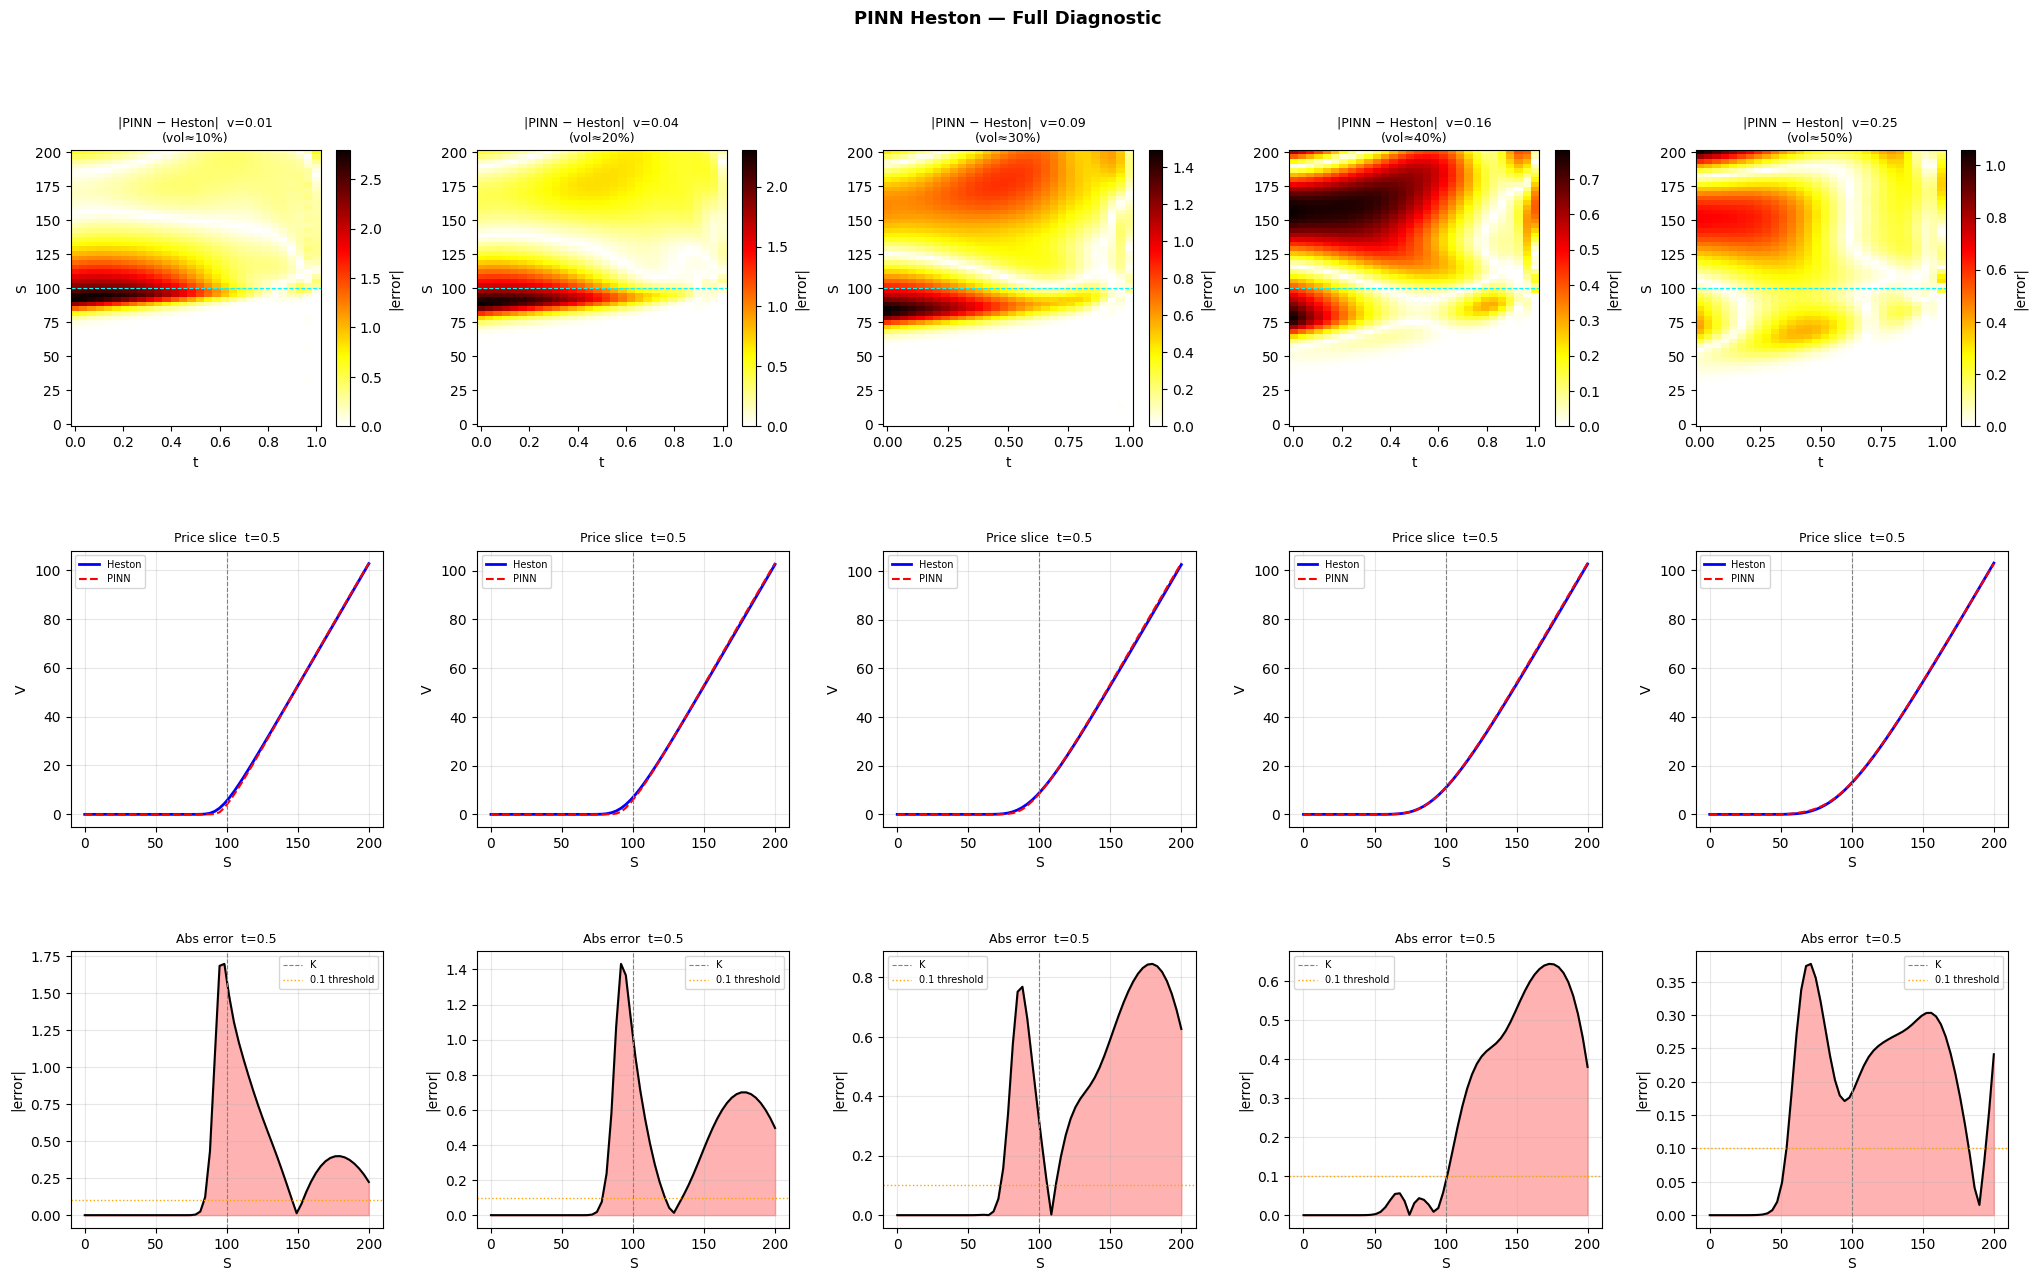

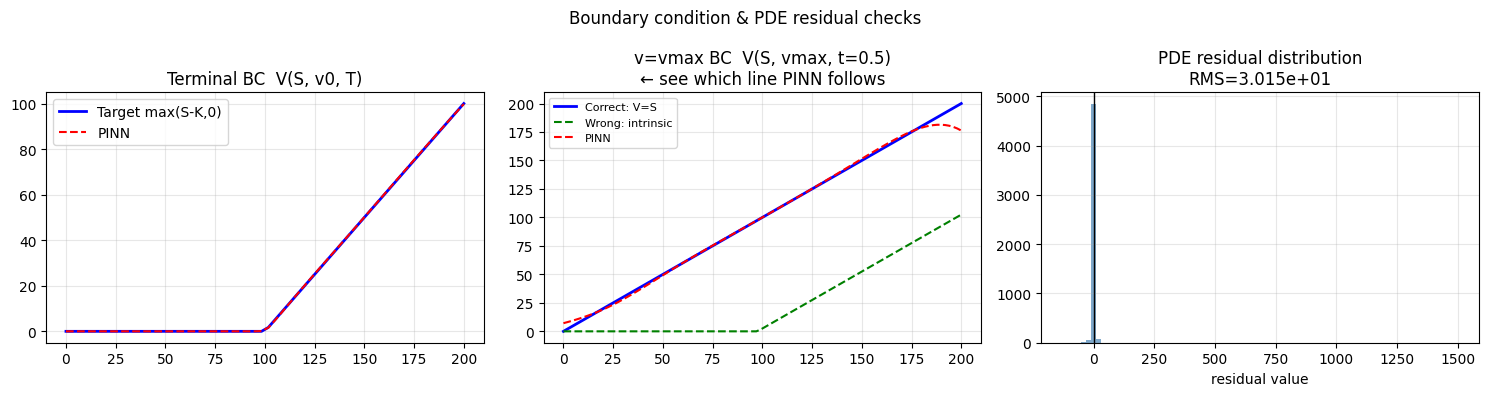


SUMMARY — what to fix next
  v=vmax loss (MSE vs wrong target): 6.26e+03  ← FIX THIS FIRST
  PDE residual RMS:                  3.01e+01  ← still high
  Terminal BC RMSE:                  1.24e-01  ← still high
  Max abs error at v=0.04:           2.31e+00  ← too large
  ATM RelL2 at v=0.04:               8.88e-02  ← too large


In [6]:
# ============================================================
# PINN HESTON — FULL DIAGNOSTIC CELL
# Drop this anywhere after training. Assumes: model_eval, heston,
# K, r, T, v0, S_min, S_max, v_min, v_max, t_min, t_max, device
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import math

model_eval.eval()

# ── Grid setup ───────────────────────────────────────────────
nS, nT = 60, 30
S_grid = np.linspace(S_min + 1e-3, S_max, nS)
t_grid = np.linspace(t_min, t_max, nT)
v_levels_diag = [0.01, 0.04, 0.09, 0.16, 0.25]   # v0 is 0.04

# ── 1. BOUNDARY CONDITION CHECKS ─────────────────────────────
print("=" * 65)
print("1. BOUNDARY CONDITION CHECKS")
print("=" * 65)

with torch.no_grad():

    # --- Terminal condition: V(S, v, T) = max(S - K, 0)
    S_T  = torch.linspace(S_min + 1e-3, S_max, 200, device=device).unsqueeze(1)
    v_T  = torch.full_like(S_T, v0)
    t_T  = torch.full_like(S_T, T)
    V_T  = model_eval(S_T, v_T, t_T).cpu().numpy().flatten()
    tgt_T = np.maximum(S_T.cpu().numpy().flatten() - K, 0.0)
    terminal_rmse = np.sqrt(np.mean((V_T - tgt_T)**2))
    terminal_max  = np.max(np.abs(V_T - tgt_T))
    print(f"  Terminal BC  RMSE: {terminal_rmse:.4e}  |  Max: {terminal_max:.4e}  ← target < 1e-2")

    # --- S=0 boundary: V(0, v, t) = 0
    t_b0 = torch.linspace(t_min, t_max, 100, device=device).unsqueeze(1)
    S_b0 = torch.zeros_like(t_b0)
    v_b0 = torch.full_like(t_b0, v0)
    V_b0 = model_eval(S_b0, v_b0, t_b0).cpu().numpy().flatten()
    s0_rmse = np.sqrt(np.mean(V_b0**2))
    s0_max  = np.max(np.abs(V_b0))
    print(f"  S=0 BC       RMSE: {s0_rmse:.4e}  |  Max: {s0_max:.4e}  ← target < 1e-3")

    # --- S=Smax boundary: V(Smax, v, t) = Smax - K*exp(-r*(T-t))
    t_b1  = torch.linspace(t_min, t_max, 100, device=device).unsqueeze(1)
    S_b1  = torch.full_like(t_b1, S_max)
    v_b1  = torch.full_like(t_b1, v0)
    V_b1  = model_eval(S_b1, v_b1, t_b1).cpu().numpy().flatten()
    tgt_b1 = S_max - K * np.exp(-r * (T - t_b1.cpu().numpy().flatten()))
    smax_rmse = np.sqrt(np.mean((V_b1 - tgt_b1)**2))
    smax_max  = np.max(np.abs(V_b1 - tgt_b1))
    print(f"  S=Smax BC    RMSE: {smax_rmse:.4e}  |  Max: {smax_max:.4e}  ← target < 1e-1")

    # --- v=0 boundary: V(S, 0, t) = max(S - K*exp(-r*(T-t)), 0)
    S_bv0 = torch.linspace(S_min + 1e-3, S_max, 100, device=device).unsqueeze(1)
    v_bv0 = torch.zeros_like(S_bv0)
    t_bv0 = torch.full_like(S_bv0, 0.5)
    V_bv0 = model_eval(S_bv0, v_bv0, t_bv0).cpu().numpy().flatten()
    tgt_bv0 = np.maximum(
        S_bv0.cpu().numpy().flatten() - K * np.exp(-r * (T - 0.5)), 0.0
    )
    v0bc_rmse = np.sqrt(np.mean((V_bv0 - tgt_bv0)**2))
    v0bc_max  = np.max(np.abs(V_bv0 - tgt_bv0))
    print(f"  v=0 BC       RMSE: {v0bc_rmse:.4e}  |  Max: {v0bc_max:.4e}  ← target < 5e-1")

    # --- v=vmax boundary: V(S, vmax, t) → S  (correct limit)
    S_bv1  = torch.linspace(S_min + 1e-3, S_max, 100, device=device).unsqueeze(1)
    v_bv1  = torch.full_like(S_bv1, v_max)
    t_bv1  = torch.full_like(S_bv1, 0.5)
    V_bv1  = model_eval(S_bv1, v_bv1, t_bv1).cpu().numpy().flatten()
    tgt_bv1_correct = S_bv1.cpu().numpy().flatten()            # ← CORRECT: V → S
    tgt_bv1_wrong   = np.maximum(                              # ← what the code uses now
        S_bv1.cpu().numpy().flatten() - K * np.exp(-r * (T - 0.5)), 0.0
    )
    vmax_correct_rmse = np.sqrt(np.mean((V_bv1 - tgt_bv1_correct)**2))
    vmax_wrong_mse    = np.mean((V_bv1 - tgt_bv1_wrong)**2)
    print(f"  v=vmax BC    RMSE vs correct target (S): {vmax_correct_rmse:.4e}")
    print(f"               MSE  vs wrong   target    : {vmax_wrong_mse:.4e}  ← this is what the model trains on!")
    print(f"  v=vmax Neumann (dV/dv RMS at boundary): {vmax_correct_rmse:.4e}  "
      f"{'✓' if vmax_correct_rmse < 5.0 else '⚠ still high'}")

# ── 2. PDE RESIDUAL ANALYSIS ──────────────────────────────────
print("\n" + "=" * 65)
print("2. PDE RESIDUAL (interior collocation)")
print("=" * 65)

N_check = 5000
S_pde = torch.rand(N_check, 1, device=device) * (S_max - S_min) + S_min
v_pde = torch.rand(N_check, 1, device=device) * (v_max - v_min) + v_min
t_pde = torch.rand(N_check, 1, device=device) * (t_max - t_min) + t_min

S_pde.requires_grad_(True); v_pde.requires_grad_(True); t_pde.requires_grad_(True)
res = model_eval._residual_core(S_pde, v_pde, t_pde)
res_np = res.detach().cpu().numpy().flatten()

# Split into ATM vs OTM/ITM
S_np_pde = S_pde.detach().cpu().numpy().flatten()
atm_mask_pde = (S_np_pde >= 75) & (S_np_pde <= 125)
print(f"  Global   residual  RMS: {np.sqrt(np.mean(res_np**2)):.4e}  |  Max: {np.max(np.abs(res_np)):.4e}")
print(f"  ATM band residual  RMS: {np.sqrt(np.mean(res_np[atm_mask_pde]**2)):.4e}  ← target < 1e-1")
print(f"  OTM/ITM  residual  RMS: {np.sqrt(np.mean(res_np[~atm_mask_pde]**2)):.4e}")

# ── 3. ACCURACY VS EXACT HESTON — MULTIPLE V SLICES ──────────
print("\n" + "=" * 65)
print("3. ACCURACY vs EXACT HESTON (multiple v levels)")
print("=" * 65)

results = {}
with torch.no_grad():
    for v_lvl in v_levels_diag:
        V_exact = np.zeros((nS, nT))
        for j, t in enumerate(t_grid):
            tau = T - t
            V_exact[:, j] = heston.price_grid(S_grid, K, v_lvl, tau)

        SS, TT = np.meshgrid(S_grid, t_grid, indexing="ij")
        VV     = np.full_like(SS, v_lvl)
        S_t    = torch.tensor(SS.reshape(-1, 1), dtype=torch.float32, device=device)
        v_t    = torch.tensor(VV.reshape(-1, 1), dtype=torch.float32, device=device)
        t_t    = torch.tensor(TT.reshape(-1, 1), dtype=torch.float32, device=device)
        V_pred = model_eval(S_t, v_t, t_t).cpu().numpy().reshape(nS, nT)

        abs_err   = np.abs(V_pred - V_exact)
        rel_l2    = np.linalg.norm(V_pred - V_exact) / (np.linalg.norm(V_exact) + 1e-12)
        rmse      = np.sqrt(np.mean((V_pred - V_exact)**2))
        max_err   = np.max(abs_err)

        atm_mask  = (S_grid >= 80) & (S_grid <= 120)
        rel_l2_atm = (np.linalg.norm((V_pred - V_exact)[atm_mask, :])
                      / (np.linalg.norm(V_exact[atm_mask, :]) + 1e-12))
        max_atm   = np.max(abs_err[atm_mask, :])

        results[v_lvl] = dict(V_exact=V_exact, V_pred=V_pred,
                               abs_err=abs_err, rel_l2=rel_l2, rmse=rmse,
                               max_err=max_err, rel_l2_atm=rel_l2_atm, max_atm=max_atm)

        flag = "⚠" if max_err > 0.3 else "✓"
        print(f"  {flag} v={v_lvl:.2f} (vol={math.sqrt(v_lvl):.0%})  "
              f"RelL2={rel_l2:.3e}  RelL2_ATM={rel_l2_atm:.3e}  "
              f"RMSE={rmse:.3e}  MaxErr={max_err:.3e}")

print("\n  Targets:  RelL2 < 1e-2  |  RelL2_ATM < 5e-2  |  MaxErr < 2e-1")

# ── 4. PLOTS ──────────────────────────────────────────────────
n_v = len(v_levels_diag)
fig = plt.figure(figsize=(5 * n_v, 14))
gs  = gridspec.GridSpec(3, n_v, figure=fig, hspace=0.45, wspace=0.3)

for col, v_lvl in enumerate(v_levels_diag):
    r_  = results[v_lvl]
    vol = math.sqrt(v_lvl)

    # Row 0 — absolute error heatmap
    ax0 = fig.add_subplot(gs[0, col])
    im  = ax0.pcolormesh(t_grid, S_grid, r_["abs_err"], cmap="hot_r", vmin=0)
    plt.colorbar(im, ax=ax0, label="|error|")
    ax0.axhline(K, color="cyan", lw=0.8, ls="--", label="K")
    ax0.set_title(f"|PINN − Heston|  v={v_lvl}\n(vol≈{vol:.0%})", fontsize=9)
    ax0.set_xlabel("t"); ax0.set_ylabel("S")

    # Row 1 — price comparison slice at t=0.5
    ax1 = fig.add_subplot(gs[1, col])
    t_idx = np.argmin(np.abs(t_grid - 0.5))
    ax1.plot(S_grid, r_["V_exact"][:, t_idx], "b-", lw=2, label="Heston")
    ax1.plot(S_grid, r_["V_pred"][:, t_idx],  "r--", lw=1.5, label="PINN")
    ax1.axvline(K, color="gray", ls="--", lw=0.8)
    ax1.set_title(f"Price slice  t=0.5", fontsize=9)
    ax1.set_xlabel("S"); ax1.set_ylabel("V"); ax1.legend(fontsize=7)
    ax1.grid(True, alpha=0.3)

    # Row 2 — pointwise error at t=0.5
    ax2 = fig.add_subplot(gs[2, col])
    ax2.plot(S_grid, r_["abs_err"][:, t_idx], "k-", lw=1.5)
    ax2.axvline(K, color="gray", ls="--", lw=0.8, label="K")
    ax2.fill_between(S_grid, r_["abs_err"][:, t_idx], alpha=0.3, color="red")
    ax2.axhline(0.1, color="orange", ls=":", lw=1, label="0.1 threshold")
    ax2.set_title(f"Abs error  t=0.5", fontsize=9)
    ax2.set_xlabel("S"); ax2.set_ylabel("|error|"); ax2.legend(fontsize=7)
    ax2.grid(True, alpha=0.3)

fig.suptitle("PINN Heston — Full Diagnostic", fontsize=13, fontweight="bold")
plt.show()

# ── 5. BOUNDARY CONDITION VISUAL CHECK ───────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))

# Terminal BC
axes2[0].plot(S_grid, np.maximum(S_grid - K, 0), "b-", lw=2, label="Target max(S-K,0)")
with torch.no_grad():
    S_t2 = torch.tensor(S_grid[:, None], dtype=torch.float32, device=device)
    v_t2 = torch.full_like(S_t2, v0)
    t_t2 = torch.full_like(S_t2, T)
    V_T2 = model_eval(S_t2, v_t2, t_t2).cpu().numpy().flatten()
axes2[0].plot(S_grid, V_T2, "r--", lw=1.5, label="PINN")
axes2[0].set_title("Terminal BC  V(S, v0, T)"); axes2[0].legend(); axes2[0].grid(alpha=0.3)

# v=vmax BC
S_arr = np.linspace(S_min + 1e-3, S_max, 100)
with torch.no_grad():
    S_t3 = torch.tensor(S_arr[:, None], dtype=torch.float32, device=device)
    v_t3 = torch.full_like(S_t3, v_max)
    t_t3 = torch.full_like(S_t3, 0.5)
    V_vmax = model_eval(S_t3, v_t3, t_t3).cpu().numpy().flatten()
axes2[1].plot(S_arr, S_arr,                                               "b-",  lw=2,   label="Correct: V=S")
axes2[1].plot(S_arr, np.maximum(S_arr - K * np.exp(-r * 0.5), 0),        "g--", lw=1.5, label="Wrong: intrinsic")
axes2[1].plot(S_arr, V_vmax,                                              "r--", lw=1.5, label="PINN")
axes2[1].set_title("v=vmax BC  V(S, vmax, t=0.5)\n← see which line PINN follows")
axes2[1].legend(fontsize=8); axes2[1].grid(alpha=0.3)

# PDE residual histogram
axes2[2].hist(res_np, bins=80, color="steelblue", alpha=0.7, edgecolor="none")
axes2[2].axvline(0, color="black", lw=1)
axes2[2].set_title(f"PDE residual distribution\nRMS={np.sqrt(np.mean(res_np**2)):.3e}")
axes2[2].set_xlabel("residual value"); axes2[2].grid(alpha=0.3)

fig2.suptitle("Boundary condition & PDE residual checks", fontsize=12)
plt.tight_layout(); plt.show()

print("\n" + "=" * 65)
print("SUMMARY — what to fix next")
print("=" * 65)
print(f"  v=vmax loss (MSE vs wrong target): {vmax_wrong_mse:.2e}  {'← FIX THIS FIRST' if vmax_wrong_mse > 1 else '✓'}")
print(f"  PDE residual RMS:                  {np.sqrt(np.mean(res_np**2)):.2e}  {'← still high' if np.sqrt(np.mean(res_np**2)) > 0.5 else '✓'}")
print(f"  Terminal BC RMSE:                  {terminal_rmse:.2e}  {'← still high' if terminal_rmse > 0.05 else '✓'}")
print(f"  Max abs error at v={v0}:           {results[v0]['max_err']:.2e}  {'← too large' if results[v0]['max_err'] > 0.2 else '✓'}")
print(f"  ATM RelL2 at v={v0}:               {results[v0]['rel_l2_atm']:.2e}  {'← too large' if results[v0]['rel_l2_atm'] > 0.02 else '✓'}")

## Evaluation

Vectorised reference pricing with `HestonPricer.price_grid` — the whole S grid is priced in one call per maturity slice, which is much faster than the old per-point `scipy.quad` loop.


In [7]:
model_eval.eval()

nS = 40
nT = 20

S_grid_np = np.linspace(S_min + 1e-3, S_max, nS)
t_grid_np = np.linspace(t_min, t_max, nT)

print("Computing Heston reference prices (vectorised)...")
V_exact_np = np.zeros((nS, nT))
for j, t in enumerate(t_grid_np):
    tau = T - t
    V_exact_np[:, j] = heston.price_grid(S_grid_np, K, v0, tau)

SS_np, TT_np = np.meshgrid(S_grid_np, t_grid_np, indexing="ij")
VV_np        = np.full_like(SS_np, v0)

S_test = torch.tensor(SS_np.reshape(-1, 1), dtype=torch.float32, device=device)
v_test = torch.tensor(VV_np.reshape(-1, 1), dtype=torch.float32, device=device)
t_test = torch.tensor(TT_np.reshape(-1, 1), dtype=torch.float32, device=device)

with torch.no_grad():
    V_pred = model_eval(S_test, v_test, t_test).cpu().numpy().reshape(nS, nT)

abs_error = np.abs(V_pred - V_exact_np)
rel_l2    = np.linalg.norm(V_pred - V_exact_np) / (np.linalg.norm(V_exact_np) + 1e-12)
rmse      = np.sqrt(np.mean((V_pred - V_exact_np)**2))
max_err   = np.max(abs_error)

atm_mask      = (S_grid_np >= 80) & (S_grid_np <= 120)
rel_l2_atm    = (np.linalg.norm(V_pred[atm_mask, :] - V_exact_np[atm_mask, :])
                 / (np.linalg.norm(V_exact_np[atm_mask, :]) + 1e-12))
max_err_atm   = np.max(abs_error[atm_mask, :])

print(f"\nEvaluation at v = {v0}  (vol = {math.sqrt(v0):.2%}):")
print(f"  Rel L2 error (global)  : {rel_l2:.6e}")
print(f"  Rel L2 error (ATM band): {rel_l2_atm:.6e}")
print(f"  RMSE                   : {rmse:.6e}")
print(f"  Max abs error (global) : {max_err:.6e}")
print(f"  Max abs error (ATM)    : {max_err_atm:.6e}")


Computing Heston reference prices (vectorised)...

Evaluation at v = 0.04  (vol = 20.00%):
  Rel L2 error (global)  : 1.185718e-02
  Rel L2 error (ATM band): 8.852586e-02
  RMSE                   : 5.159856e-01
  Max abs error (global) : 2.260850e+00
  Max abs error (ATM)    : 2.260850e+00


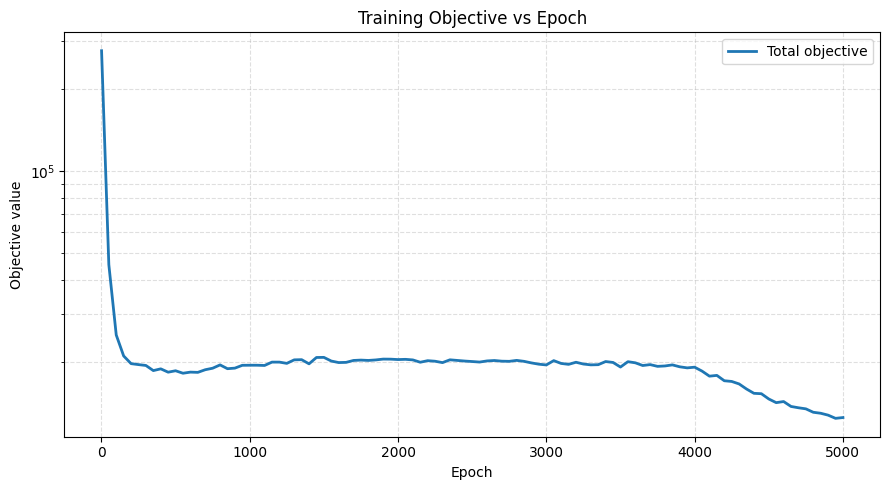

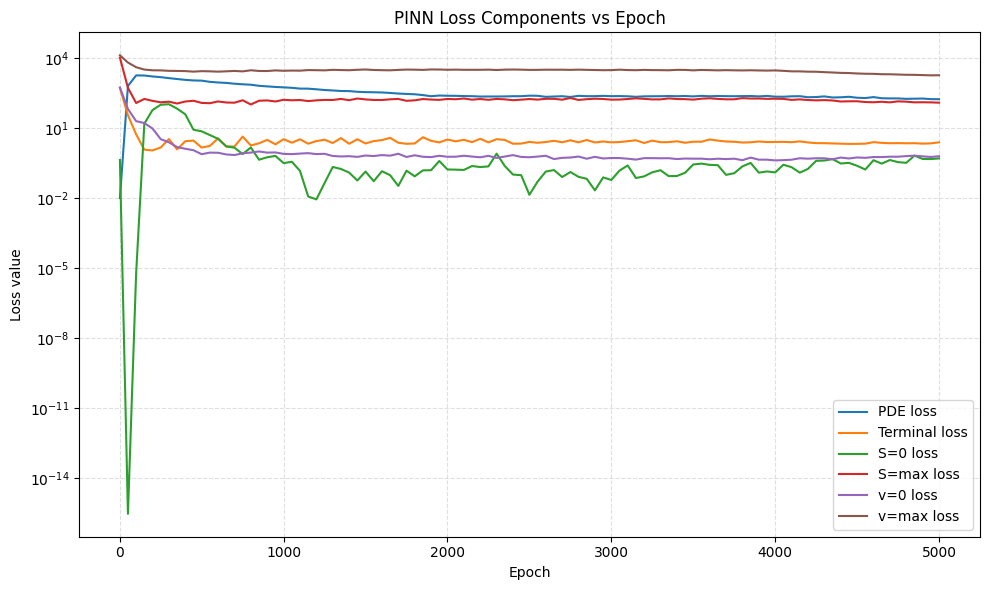


Final training objective:
  Total objective : 1.248248e+04
  PDE loss        : 1.708820e+02
  Terminal loss   : 2.423299e+00
  S=0 loss        : 4.950121e-01
  S=max loss      : 1.212470e+02
  v=0 loss        : 6.171135e-01
  v=max loss      : 1.813972e+03


In [8]:
# ============================================================
# Objective vs epoch
# ============================================================

history_df = pd.DataFrame(history)

plt.figure(figsize=(9, 5))

plt.plot(
    history_df["epoch"],
    history_df["total_loss"],
    linewidth=2,
    label="Total objective",
)

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Objective value")
plt.title("Training Objective vs Epoch")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

plt.plot(history_df["epoch"], history_df["pde_loss"], label="PDE loss")
plt.plot(history_df["epoch"], history_df["terminal_loss"], label="Terminal loss")
plt.plot(history_df["epoch"], history_df["S0_loss"], label="S=0 loss")
plt.plot(history_df["epoch"], history_df["Smax_loss"], label="S=max loss")
plt.plot(history_df["epoch"], history_df["v0_loss"], label="v=0 loss")
plt.plot(history_df["epoch"], history_df["vmax_loss"], label="v=max loss")

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss value")
plt.title("PINN Loss Components vs Epoch")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

print("\nFinal training objective:")
print(f"  Total objective : {history_df['total_loss'].iloc[-1]:.6e}")
print(f"  PDE loss        : {history_df['pde_loss'].iloc[-1]:.6e}")
print(f"  Terminal loss   : {history_df['terminal_loss'].iloc[-1]:.6e}")
print(f"  S=0 loss        : {history_df['S0_loss'].iloc[-1]:.6e}")
print(f"  S=max loss      : {history_df['Smax_loss'].iloc[-1]:.6e}")
print(f"  v=0 loss        : {history_df['v0_loss'].iloc[-1]:.6e}")
print(f"  v=max loss      : {history_df['vmax_loss'].iloc[-1]:.6e}")

## Pointwise Comparison Table


In [9]:
def compare_prices_table(model, heston, S_list, v0, T, K, t_value=0.5):
    model_eval.eval()
    tau = T - t_value
    with torch.no_grad():
        S_t = torch.tensor([[float(s)] for s in S_list], dtype=torch.float32, device=device)
        v_t = torch.full_like(S_t, float(v0))
        t_t = torch.full_like(S_t, float(t_value))
        pinn_p = model_eval(S_t, v_t, t_t).cpu().numpy().flatten()

    exact_p  = heston.price_grid(np.array(S_list, dtype=float), K, v0, tau)
    abs_err  = np.abs(pinn_p - exact_p)
    rel_err  = abs_err / np.maximum(np.abs(exact_p), 0.1)

    return pd.DataFrame({
        "S": S_list, "t": t_value, "v": v0,
        "PINN_price": pinn_p, "Exact_Heston": exact_p,
        "Abs_error": abs_err, "Rel_error_%": rel_err * 100,
    })

S_values   = [40, 60, 80, 90, 100, 110, 120, 140, 160, 180]
df_compare = compare_prices_table(model, heston, S_values, v0, T, K, t_value=0.5)

atm_rows    = df_compare[df_compare.S.between(80, 120)]
rel_l2_full = (np.linalg.norm(df_compare.PINN_price - df_compare.Exact_Heston)
               / (np.linalg.norm(df_compare.Exact_Heston) + 1e-12))
rel_l2_atm  = (np.linalg.norm(atm_rows.PINN_price - atm_rows.Exact_Heston)
               / (np.linalg.norm(atm_rows.Exact_Heston) + 1e-12))

print(f"{'='*55}")
print(f" t=0.5, v={v0}  (vol={math.sqrt(v0):.2%})")
print(f"{'='*55}")
print(f" Rel L2 (full slice)  : {rel_l2_full:.6e}")
print(f" Rel L2 (ATM [80,120]): {rel_l2_atm:.6e}")
print(f" Max rel error        : {df_compare['Rel_error_%'].max():.4f}%")
df_compare.round(6)


 t=0.5, v=0.04  (vol=20.00%)
 Rel L2 (full slice)  : 1.631037e-02
 Rel L2 (ATM [80,120]): 5.807900e-02
 Max rel error        : 89.9732%


,S,t,v,PINN_price,Exact_Heston,Abs_error,Rel_error_%
0,40,0.5,0.04,0.000000,0.000000,0.000000,0.000001
1,60,0.5,0.04,0.000023,0.000004,0.000019,0.019111
2,80,0.5,0.04,0.015168,0.151279,0.136110,89.973248
3,90,0.5,0.04,0.600626,1.855416,1.254790,67.628482
4,100,0.5,0.04,5.884371,6.837200,0.952830,13.935961
5,110,0.5,0.04,13.974931,14.410045,0.435114,3.019521
6,120,0.5,0.04,23.205072,23.329489,0.124417,0.533303
7,140,0.5,0.04,42.844437,42.648469,0.195968,0.459496
8,160,0.5,0.04,63.069862,62.510866,0.558997,0.894239
9,180,0.5,0.04,83.179939,82.479953,0.699986,0.848674


## Plots


### idk

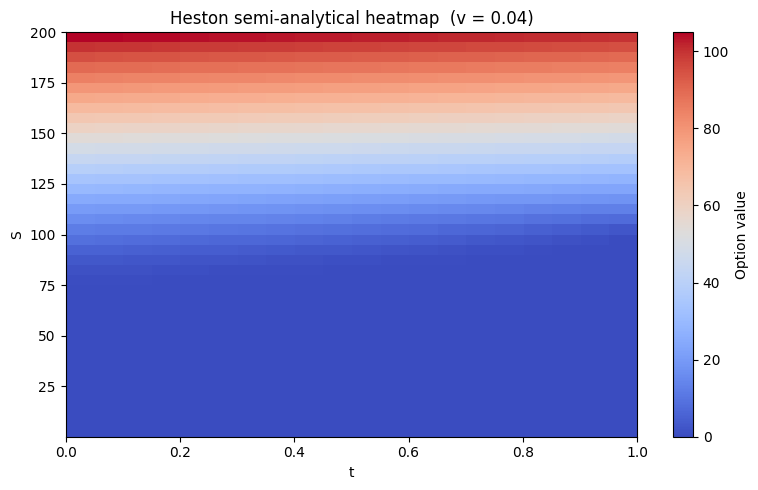


 t=0.25, v=0.04  (tau=0.750)
 Rel L2 (full slice)  : 1.511167e-02
 Rel L2 (ATM [80,120]): 1.101642e-01
 RMSE                 : 6.649028e-01
 Max abs error        : 2.065896e+00
 Max rel error        : 95.6027%


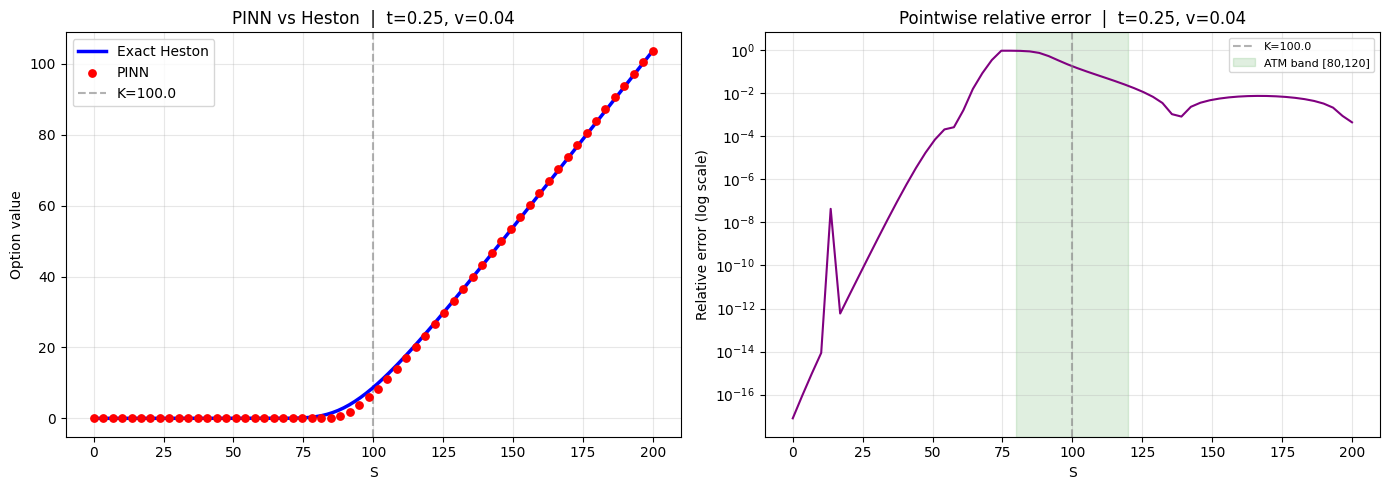


 t=0.5, v=0.04  (tau=0.500)
 Rel L2 (full slice)  : 1.111759e-02
 Rel L2 (ATM [80,120]): 7.156814e-02
 RMSE                 : 4.796544e-01
 Max abs error        : 1.370037e+00
 Max rel error        : 89.9240%


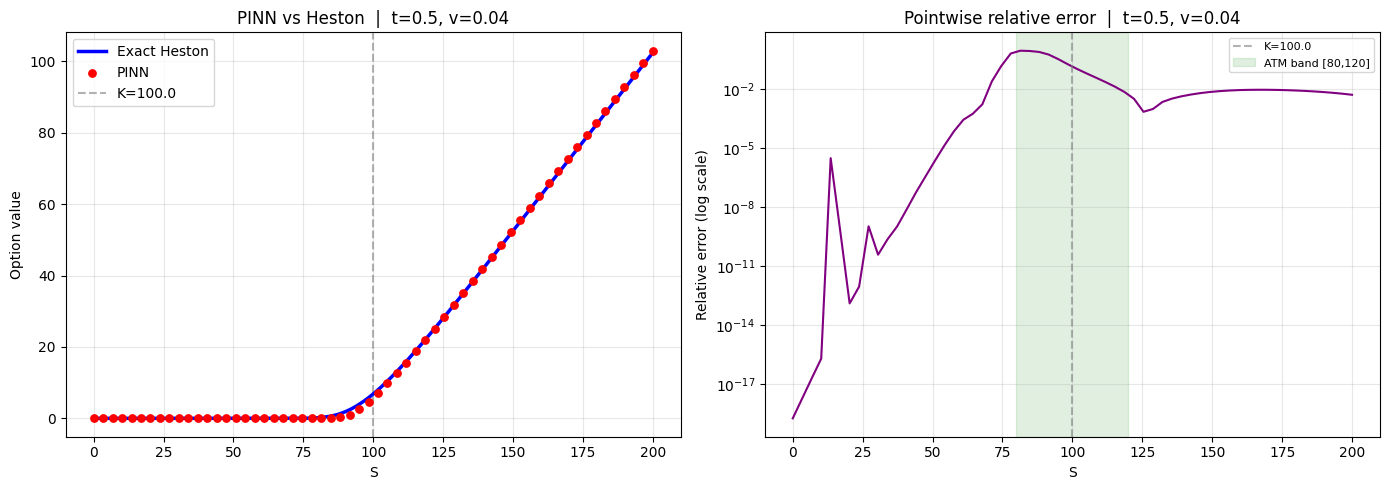


 t=0.75, v=0.04  (tau=0.250)
 Rel L2 (full slice)  : 6.887187e-03
 Rel L2 (ATM [80,120]): 2.803556e-02
 RMSE                 : 2.913898e-01
 Max abs error        : 5.985321e-01
 Max rel error        : 62.1672%


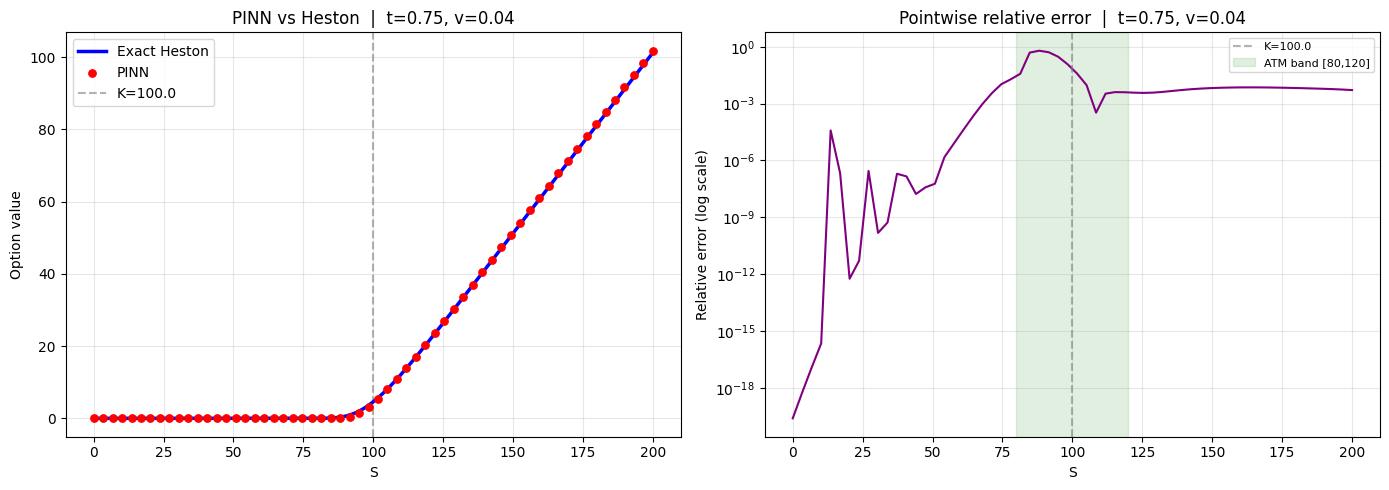

In [10]:
def plot_heston_heatmap(heston, v0, T, K, S_min, S_max, t_min, t_max, nS=40, nT=20):
    S_vals = np.linspace(S_min + 1e-3, S_max, nS)
    t_vals = np.linspace(t_min, t_max, nT)
    V_heston = np.zeros((nS, nT))
    for j, t in enumerate(t_vals):
        V_heston[:, j] = heston.price_grid(S_vals, K, v0, T - t)
    plt.figure(figsize=(8, 5))
    im = plt.imshow(V_heston, extent=[t_vals.min(), t_vals.max(), S_vals.min(), S_vals.max()],
                    origin="lower", aspect="auto", cmap="coolwarm")
    plt.xlabel("t"); plt.ylabel("S")
    plt.title(f"Heston semi-analytical heatmap  (v = {v0})")
    plt.colorbar(im, label="Option value"); plt.tight_layout(); plt.show()


def plot_single_slice(model, heston, v0, T, K, S_min, S_max, t_value=0.5,
                      nS_line=200, nS_scatter=60):
    model_eval.eval()
    tau          = T - t_value
    S_line_np    = np.linspace(S_min + 1e-3, S_max, nS_line)
    S_scatter_np = np.linspace(S_min + 1e-3, S_max, nS_scatter)

    V_heston_line    = heston.price_grid(S_line_np,    K, v0, tau)
    V_heston_scatter = heston.price_grid(S_scatter_np, K, v0, tau)

    S_t = torch.tensor(S_scatter_np.reshape(-1, 1), dtype=torch.float32, device=device)
    v_t = torch.full_like(S_t, float(v0))
    t_t = torch.full_like(S_t, float(t_value))
    with torch.no_grad():
        V_pinn = model_eval(S_t, v_t, t_t).cpu().numpy().flatten()

    abs_err = np.abs(V_pinn - V_heston_scatter)
    rel_err = abs_err / np.maximum(np.abs(V_heston_scatter), 0.1)
    atm_mask = (S_scatter_np >= 80) & (S_scatter_np <= 120)
    rel_l2_slice = np.linalg.norm(V_pinn - V_heston_scatter) / (np.linalg.norm(V_heston_scatter) + 1e-12)
    rel_l2_atm   = (np.linalg.norm(V_pinn[atm_mask] - V_heston_scatter[atm_mask])
                    / (np.linalg.norm(V_heston_scatter[atm_mask]) + 1e-12))

    print(f"\n{'='*55}")
    print(f" t={t_value}, v={v0}  (tau={tau:.3f})")
    print(f"{'='*55}")
    print(f" Rel L2 (full slice)  : {rel_l2_slice:.6e}")
    print(f" Rel L2 (ATM [80,120]): {rel_l2_atm:.6e}")
    print(f" RMSE                 : {np.sqrt(np.mean((V_pinn - V_heston_scatter)**2)):.6e}")
    print(f" Max abs error        : {np.max(abs_err):.6e}")
    print(f" Max rel error        : {np.max(rel_err):.4%}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax = axes[0]
    ax.plot(S_line_np, V_heston_line, color="blue", lw=2.5, label="Exact Heston", zorder=3)
    ax.scatter(S_scatter_np, V_pinn, color="red", s=28, label="PINN", zorder=4)
    ax.axvline(K, color="gray", ls="--", alpha=0.6, label=f"K={K}")
    ax.set_xlabel("S"); ax.set_ylabel("Option value")
    ax.set_title(f"PINN vs Heston  |  t={t_value}, v={v0}")
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.semilogy(S_scatter_np, rel_err, color="purple", lw=1.5)
    ax.axvline(K, color="gray", ls="--", alpha=0.6, label=f"K={K}")
    ax.axvspan(80, 120, alpha=0.12, color="green", label="ATM band [80,120]")
    ax.set_xlabel("S"); ax.set_ylabel("Relative error (log scale)")
    ax.set_title(f"Pointwise relative error  |  t={t_value}, v={v0}")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


plot_heston_heatmap(heston, v0, T, K, S_min, S_max, t_min, t_max)
for t_val in [0.25, 0.5, 0.75]:
    plot_single_slice(model_eval, heston, v0, T, K, S_min, S_max, t_value=t_val)


### Error Heatmap


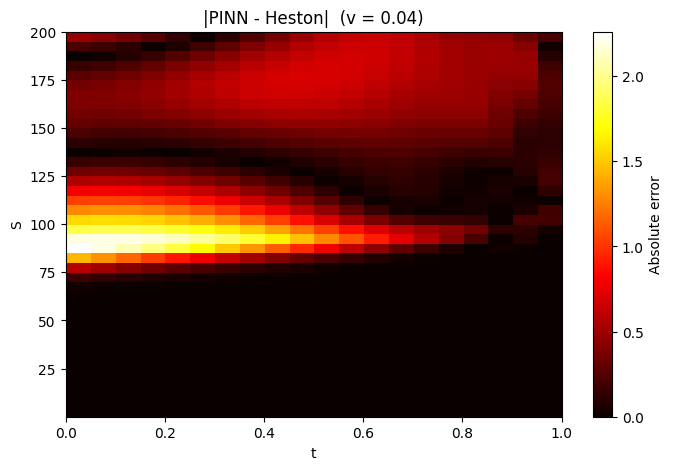

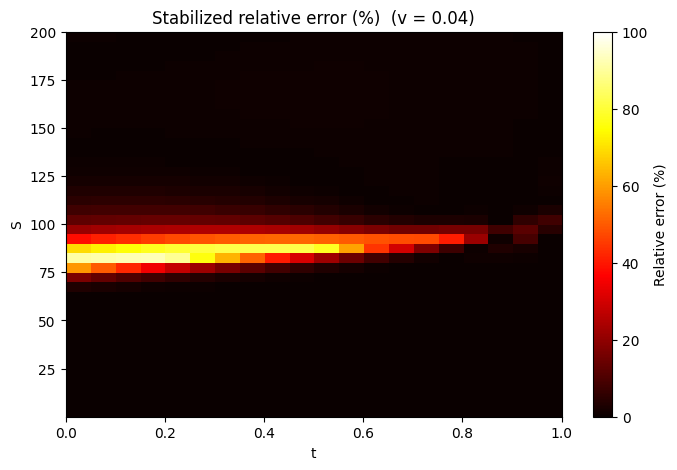

In [11]:
def plot_error_heatmap(model, heston, v0, T, K, S_min, S_max, t_min, t_max, nS=40, nT=20):
    model.eval()
    S_vals = np.linspace(S_min + 1e-3, S_max, nS)
    t_vals = np.linspace(t_min, t_max, nT)

    V_heston = np.zeros((nS, nT))
    for j, t in enumerate(t_vals):
        V_heston[:, j] = heston.price_grid(S_vals, K, v0, T - t)

    SS_np, TT_np = np.meshgrid(S_vals, t_vals, indexing="ij")
    S_t = torch.tensor(SS_np.reshape(-1, 1), dtype=torch.float32, device=device)
    v_t = torch.full_like(S_t, float(v0))
    t_t = torch.tensor(TT_np.reshape(-1, 1), dtype=torch.float32, device=device)

    with torch.no_grad():
        V_pinn = model(S_t, v_t, t_t).cpu().numpy().reshape(nS, nT)

    abs_err = np.abs(V_pinn - V_heston)

    # Stabilized relative error: avoids explosion when Heston price is near zero.
    price_floor = 1.0
    rel_err = abs_err / np.maximum(np.abs(V_heston), price_floor) * 100

    plt.figure(figsize=(8, 5))
    im = plt.imshow(abs_err, extent=[t_vals.min(), t_vals.max(), S_vals.min(), S_vals.max()],
                    origin="lower", aspect="auto", cmap="hot")
    plt.xlabel("t"); plt.ylabel("S")
    plt.title(f"|PINN - Heston|  (v = {v0})")
    plt.colorbar(im, label="Absolute error")
    plt.show()

    plt.figure(figsize=(8, 5))
    im = plt.imshow(rel_err, extent=[t_vals.min(), t_vals.max(), S_vals.min(), S_vals.max()],
                    origin="lower", aspect="auto", cmap="hot", vmin=0, vmax=100)
    plt.xlabel("t"); plt.ylabel("S")
    plt.title(f"Stabilized relative error (%)  (v = {v0})")
    plt.colorbar(im, label="Relative error (%)")
    plt.show()

plot_error_heatmap(model_eval, heston, v0, T, K, S_min, S_max, t_min, t_max)

### PINN across variance levels


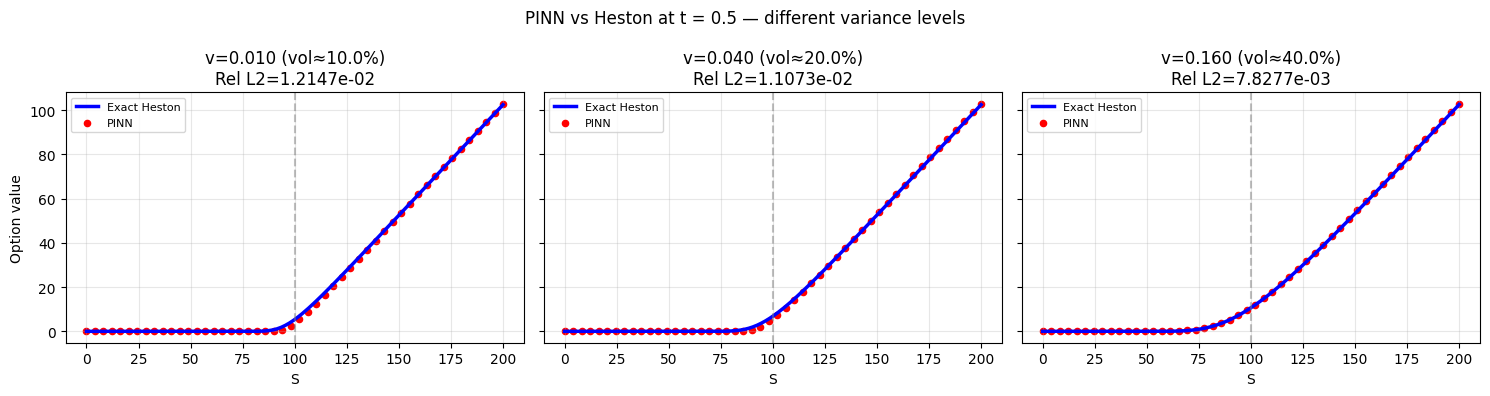

In [12]:
def plot_pinn_vs_heston_multiple_v(model, heston, v_levels, T, K,
                                    S_min, S_max, t_value=0.5):
    model_eval.eval()
    tau = T - t_value
    S_line_np    = np.linspace(S_min + 1e-3, S_max, 200)
    S_scatter_np = np.linspace(S_min + 1e-3, S_max, 50)
    fig, axes = plt.subplots(1, len(v_levels), figsize=(5 * len(v_levels), 4), sharey=True)
    if len(v_levels) == 1:
        axes = [axes]
    for ax, v_lvl in zip(axes, v_levels):
        V_hl = heston.price_grid(S_line_np,    K, v_lvl, tau)
        V_hs = heston.price_grid(S_scatter_np, K, v_lvl, tau)
        S_t  = torch.tensor(S_scatter_np.reshape(-1, 1), dtype=torch.float32, device=device)
        v_t  = torch.full_like(S_t, float(v_lvl))
        t_t  = torch.full_like(S_t, float(t_value))
        with torch.no_grad():
            V_pinn = model_eval(S_t, v_t, t_t).cpu().numpy().flatten()
        rel_l2 = np.linalg.norm(V_pinn - V_hs) / (np.linalg.norm(V_hs) + 1e-12)
        ax.plot(S_line_np, V_hl, color="blue", lw=2.5, label="Exact Heston")
        ax.scatter(S_scatter_np, V_pinn, color="red", s=20, label="PINN")
        ax.axvline(K, color="gray", ls="--", alpha=0.5)
        ax.set_title(f"v={v_lvl:.3f} (vol≈{math.sqrt(v_lvl):.1%})\nRel L2={rel_l2:.4e}")
        ax.set_xlabel("S"); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
    axes[0].set_ylabel("Option value")
    fig.suptitle(f"PINN vs Heston at t = {t_value} — different variance levels", fontsize=12)
    plt.tight_layout(); plt.show()

plot_pinn_vs_heston_multiple_v(
    model_eval, heston, v_levels=[0.01, 0.04, 0.16],
    T=T, K=K, S_min=S_min, S_max=S_max, t_value=0.5
)
